In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

In [ ]:

iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


In [ ]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

In [ ]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])


In [ ]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [ ]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


In [ ]:
model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

In [ ]:
torch.nn.init.uniform_(model.weight, -0.1, 0.1)
model.weight

/tmp/ipykernel_2187/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

In [ ]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [ ]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

3) Crie duas listas w0_list e w1_list para guardar a evolução dos valores dos parâmetros durante o laço de treinamento. Modifique o exemplo do gráfico tipo scatter plot para visualizar a variação dos parâmetros do modelo duas dimensões. Marque neste gráfico o valor ótimo do parâmetro dado pela solução analítica.

In [ ]:
num_epochs = 100
learning_rate = 0.5
torch.nn.init.zeros_(model.weight)
w0_list = []
w1_list = []

for epoch in range(num_epochs):
    # forward - predict
    y_pred = model(x_train_bias)

    # loss cálculo da função de perda
    loss = torch.mean((y_pred - y_train)**2)

    # backward propagation - cálculo gradient
    loss.backward()


    with torch.no_grad():
        # 1. Gradiente descendente
        model.weight -= learning_rate * model.weight.grad

        # 2. Armazenar os valores nas listas
        w0_list.append(model.weight[0, 0].item())
        w1_list.append(model.weight[0, 1].item())

        # 3. Zerar o gradiente
        model.weight.grad.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss.item()))

Epoch[20/100], loss: 0.022971
Epoch[40/100], loss: 0.021430
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando loss.data? Por que precisa do data?

Evitar vazamento de memoria por OOM e ter uma melhor performance pois loss.data é somente o valor numérico e não o tensor inteiro. loss.item() também pode ser usado.

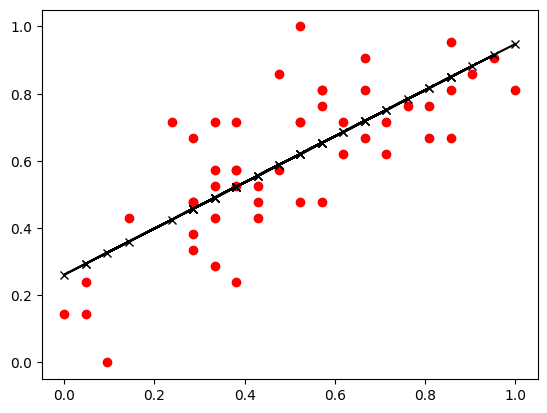

In [ ]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()


In [ ]:
w_dic = model.state_dict()
w_dic


OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

In [ ]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))


tensor([[0.2613, 0.6865]])


2.Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já treinados.

In [ ]:
y_pred_final = model(x_train_bias)
mse_loss = torch.mean((y_pred_final - y_train)**2)
print(f'MSE Loss: {mse_loss.item():.6f}')

MSE Loss: 0.021169


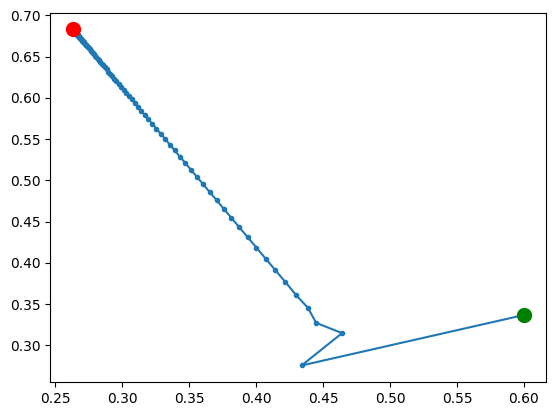

In [ ]:
fig, ax = plt.subplots()
ax.plot(w0_list, w1_list, 'o-', markersize=3)
ax.scatter(w0_list[0], w1_list[0], color='green', s=100, zorder=5)
ax.scatter(w0_list[-1], w1_list[-1], color='red', s=100, zorder=5)
plt.show()

## Teste

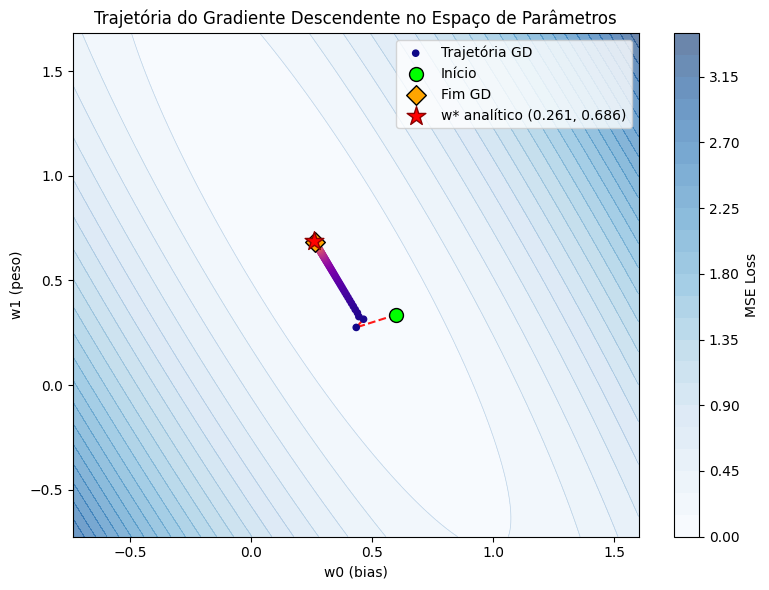

In [ ]:
# Solução analítica ideal
w0_opt = w_opt[0].item()
w1_opt = w_opt[1].item()

# Superfície de perda
w0_range = np.linspace(min(w0_list) - 1, max(w0_list) + 1, 200)
w1_range = np.linspace(min(w1_list) - 1, max(w1_list) + 1, 200)
W0, W1 = np.meshgrid(w0_range, w1_range)

Loss = np.zeros_like(W0)
x_np = x_train_bias.detach().numpy()
y_np = y_train.detach().numpy().flatten()

W = np.stack([W0, W1], axis=-1)

Y_pred = W @ x_np.T

# MSE vetorizado
Loss = np.mean((Y_pred - y_np) ** 2, axis=-1)  # (200, 200)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Fundo pri
contour = ax.contourf(W0, W1, Loss, levels=30, cmap='Blues', alpha=0.6)
ax.contour(W0, W1, Loss, levels=30, colors='steelblue', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=ax, label='MSE Loss')

# Trajetória
ax.plot(w0_list, w1_list, color='white', linewidth=1.5, alpha=0.9)

# Scatter por cima da linha
ax.scatter(w0_list, w1_list, c=range(len(w0_list)), cmap='plasma',
           s=20, zorder=5, label='Trajetória GD')

# Início e fim
ax.scatter(w0_list[0], w1_list[0], color='lime', s=100, zorder=6,
           edgecolors='black', linewidths=1, label='Início')
ax.scatter(w0_list[-1], w1_list[-1], color='orange', s=100, zorder=6,
           marker='D', edgecolors='black', linewidths=1, label='Fim GD')

# Solução analítica
ax.scatter(w0_opt, w1_opt, color='red', s=200, zorder=7,
           marker='*', edgecolors='darkred', linewidths=1,
           label=f'w* analítico ({w0_opt:.3f}, {w1_opt:.3f})')
ax.plot(w0_list, w1_list, color='red', linewidth=1.5, alpha=0.9,
        linestyle='dashed')
ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (peso)')
ax.set_title('Trajetória do Gradiente Descendente no Espaço de Parâmetros')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()